In [ ]:
from typing import TypedDict, Annotated, Sequence, List,Literal
from langgraph.graph import StateGraph, END
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder,PromptTemplate
from langgraph.graph import StateGraph, END, add_messages,MessagesState

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from pydantic import BaseModel, Field

from langchain.agents import initialize_agent, AgentType
import pandas as pd

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_experimental.tools import PythonREPLTool
from langchain.document_loaders import PyPDFLoader, TextLoader, UnstructuredWordDocumentLoader
from langchain_community.document_loaders import UnstructuredFileLoader


from langchain_core.runnables import RunnableSequence, RunnableParallel, RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from langgraph.checkpoint.memory import MemorySaver
from uuid import uuid4

import os
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
class Agent_state(TypedDict):
    messages : Annotated[List, add_messages]
    query : str
    uploaded_files_info : dict[str]
    uploaded_dataframes : dict[str, pd.DataFrame]
    uploaded_docs: dict[str, List[str]]  # Assuming this is a list of file paths
    context : List[str]
    output : str
    next_action : str
    action_reason:str
    max_attempts: int
    called_agents : List[str]

In [3]:
def data_reader(state:Agent_state):
    # Folder containing your files
    folder_path = "/Users/yogeshagrawal/Desktop/Gen AI/32.Agentic_AI/documents"

    supported_extensions = {
        '.csv': pd.read_csv,
        '.xlsx': pd.read_excel,
        '.xls': pd.read_excel,
        '.json': pd.read_json,
        '.parquet': pd.read_parquet
    }

    file_info = {}
    # dataframes = {}

    files = os.listdir(folder_path)
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        ext = os.path.splitext(file_name)[1].lower()

        if os.path.isfile(file_path) and ext in supported_extensions:
            try:
                df = supported_extensions[ext](file_path)
                key = os.path.splitext(file_name)[0]
                # dataframes[key] = df
                print(f"✅ Loaded {file_name} as dataframes['{key}']")

                # # Extract info
                file_info[key] = {
                "file_name": key,
                "file_type": ext[1:],  # Remove the dot
                "num_pages": len(df),  # Assuming each row is a page
                # "data": df  # Sample first 100 characters
                "data":df.to_dict(orient="records")
            }
            except Exception as e:
                print(f"❌ Error reading {file_name}: {e}")
        
        elif os.path.isfile(file_path) and ext == '.pdf':
            key = os.path.splitext(file_name)[0]
            loader = PyPDFLoader(file_path)
            docs = loader.load()
            print(f"✅ Loaded {file_name} as pdf ['{key}']")
            file_info[key] = {
                "file_name": key,
                "file_type": "pdf",
                "num_pages": len(docs),
                "data": docs  # Sample first 100 characters
            }

        elif os.path.isfile(file_path) and ext == '.txt':
            key = os.path.splitext(file_name)[0]  
            loader = TextLoader(file_path, encoding="utf-8")
            docs = loader.load()
            file_info[key] = {
                "file_name": key,
                "file_type": "txt",
                "num_pages": len(docs),
                "data": docs  # Sample first 100 characters
            }

        elif os.path.isfile(file_path) and ext == '.docx':
            key = os.path.splitext(file_name)[0]
            # Use UnstructuredWordDocumentLoader for .docx files
            loader = UnstructuredWordDocumentLoader(file_path)
            docs = loader.load()
            file_info[key] = {
                "file_name": key,
                "file_type": "docx",
                "num_pages": len(docs),
                "data": docs  # Sample first 100 characters
            }

        elif os.path.isfile(file_path) and ext == '.md':
            key = os.path.splitext(file_name)[0]
            loader  = UnstructuredFileLoader(file_path)
            docs = loader.load()
            file_info[key] = {
                "file_name": key,
                "file_type": "markdown",
                "num_pages": len(docs),
                "data": docs  # Sample first 100 characters
            }

        else:
            print(f"Unsupported file type: {ext}")

    state['uploaded_files_info'] = file_info
    # state['uploaded_dataframes'] = dfs
    

    return state

In [4]:
def context_generator(state:Agent_state):
    """
    Function to read data and generate context for the agent.
    """
    # Here you can implement logic to read data from files and generate context
    # For simplicity, we will just return the query and context as is
    dfs = {}
    cleaned_data = {}
    # dataframes = state['uploaded_files_info']
    files_info = state['uploaded_files_info']
    # print(f"📂 Files info: {files_info}")
    if not files_info:
        print("❌ No file info found.")
    else:
        context = ""
        for key in files_info.keys():
            if files_info[key]["file_type"] in ['csv', 'xlsx', 'xls', 'json', 'parquet']:
                # df = files_info[key]["data"]

                ########## to use in the memory checkpointer ##############
                df = pd.DataFrame(files_info[key]["data"])
                print(f"📄 DataFrame '{key}' loaded with shape {df.shape}")
                # df_{key} = df
                # dfs[f"df_{key}"] = df
                ############### to use in the memory checkpointer ##############
                dfs[f"df_{key}"] = df.to_dict(orient="records")
                # Generate context from the first DataFrame
                context += f"""
                This data is a Pandas DataFrame with the following properties:
                file_name : {key}
                dataframe_name: df_{key}
                Shape: {df.shape}
                Columns: {df.columns.to_list()}
                Sample Data: {df.head()}
                Description: {df.describe().to_dict()}
                """
            else:
                data = files_info[key]["data"]
                print(f"documents are {data}")
                # cleaned_data[key] = [doc.page_content for doc in data if hasattr(doc, 'page_content')]
                cleaned_data[key] = data
                print(f"📄 Document '{key}' loaded with {len(data)} pages")
                # Generate context from the document
                context += f"""
                This document is a {files_info[key]['file_type']} file with the following properties:
                file_name : {key}
                Type: {files_info[key]['file_type']}
                Number of Pages: {files_info[key]['num_pages']}
                Sample Data: {cleaned_data[key][0].page_content[0:100]}  # Sample first 100 characters
                """


    context_prompt_template = f""" 
    The data you are working with have following details:
    {context}
    You can use this information to answer questions about the data.
    """

    # print(f"📄 Context generated:\n{context_prompt_template}")
    state['context'] = context_prompt_template
    state['uploaded_dataframes'] = dfs
    state['uploaded_docs'] = cleaned_data  # Store cleaned data for documents
    return state

In [5]:
class Supervisor_schema(BaseModel):

    next_step: Literal["code_executor","external_web_search","internal_RAG", "finish"] = Field(
        description="The next step to take after the current step is completed."
        "'code_executor' when user input requires some code to run in the uploaded data "
        "'external_web_search' when user input requires some facts, context or external information which is not present in uploaded data or text, "
        "'internal_RAG' when user input requires retrieving information from uploaded pdf, text, or other documents"
        "'finish' when you are satisfied with the output and want to finish the conversation."
    )

    reason: str = Field(
        description="Detailed justification for the routing decision, explaining the rationale behind selecting the particular specialist and how this advances the task toward completion."
    )

In [6]:
def supervisor_node(state:Agent_state):

    system_prompt = (
    f"""You are a workflow supervisor managing a team of four specialized agents: Code Executor, External Web Search, Internal RAG System, and Finish.
        Your job is to select the most suitable agent based on the current query and context, ensuring efficiency, accuracy, and completeness.
    🧠 Team Members:
                    1. Code Executor: Prioritized first. It writes and executes Python code based on uploaded data files and answers data-specific queries.
                    2. External Web Search: Searches online sources for queries unrelated to the uploaded documents or data.
                    3. Internal RAG System: Retrieves information from uploaded PDFs, text, or structured internal documents.
                    4. Finish: Select this only when the query has been fully and satisfactorily answered.
    📋 Your Responsibilities:
                    - Assess whether the query has already been answered based on existing context or agent outputs.
                    - Assign only one agent at each step, and avoid reassigning an agent already called unless new information or clarification is required.
                    - Track which agents have already been called. Do not loop back unnecessarily.
    - Select 'finish' only when:
        - The user's question has been clearly answered.
        - No further actions or clarifications are required.
    - Ensure the final output is complete, accurate, and clearly addresses the user's query.

    🚦Decision-Making Rules:
    - Start with Code Executor if the query seems related to uploaded files or can be answered with code.
    - Use Internal RAG for document-based lookups.
    - Use External Web Search only when the answer isn't available internally.
    - Proceed to Finish only if the question has been resolved to satisfaction. Clearly explain why no further agents are needed.

    🔍 Current Workflow State:
    query: {state['query']}
    context: {state['context']}
    agents_already_called: {state.get('called_agents', [])}
    last_intermediate_step: {state.get('messages', '')[-1].content if state.get('messages') else 'No answers yet.'}
    last_output: {state.get('output', '') if state.get('output') else 'No output generated yet.'}    

    Please indicate your next chosen agent and the reason for this selection.
    """)

    print(state['query'])

    if state['messages']:
        # Append the last user message to the system prompt
        # last_user_message = state['messages'][-1]
        # print(f"Last User Message: {last_user_message.content}")
        # if isinstance(last_user_message, HumanMessage):
        #     system_prompt += f"\nLast User Message: {last_user_message.content}"
        # messages = [{"role": "system", "content": system_prompt},] +  [{"role": "user", "content": last_user_message.content}]
        state['max_attempts'] += 1
        print(f"Max attempts incremented to {state['max_attempts']}")
    else:
        print("No previous messages found, using system prompt only.")
        # messages = [{"role": "system", "content": system_prompt}] 
        state['max_attempts'] = 0

    messages = [{"role": "system", "content": system_prompt}] 
    llm = ChatOpenAI(model="gpt-4o", temperature=0)

    response = llm.with_structured_output(Supervisor_schema).invoke(messages)

    next = response.next_step
    reason = response.reason

    state['next_action'] = next
    state['action_reason'] = reason
    print(f"Supervisor Decision: Next Agent - {next}, Reason - {reason}")

    if 'called_agents' not in state:
        state['called_agents'] = []
        
    state['called_agents'].append(next)

    state['messages'].append(HumanMessage(content = f"Supervisor Decision: Next Agent - {next}, Reason - {reason}", name = "Supervisor"))

    # print(state['messages'])

    return state

    

In [7]:
def supervisor_routing(state: Agent_state):
    """
    Supervisor routing function to determine the next action based on the current state.
    """
    # Here you can implement logic to decide the next action based on the state
    # For simplicity, we will just return the state as is
    route = state['next_action']
    
    print(f"🧭 Routing to: {route}")

    if state['max_attempts'] > 5:
        print("❌ Maximum attempts exceeded. Ending workflow.")
        route = "finish"
        return END
    else:
        if route == "code_executor":
            return "query_executor"
        elif route == "external_web_search":
            return "external_web_search"
        elif route == "internal_RAG":
            return "internal_RAG"
        elif route == "finish":
            return END
        else:
            raise ValueError(f"Unknown route: {route}")

In [9]:
def query_executor(state: Agent_state):
    """
    Function to execute the query using the context.
    """
    query = state['query']
    context = state['context']

    system_message = """ You are a advance Python Agent.
    Your job is to understand the provided context and answer the write proper Python code to answer the user's query.
    You can execute Python code to answer questions about the data. data in context is just sample data for your understanding. 
    Your Job is provide me python code to get the final response. 
    1. Please make sure to comment the sample data in the final code
    2. You can only use appropriate dataframe provided in the context.
    3. You must ensure dataframe must be from provided context only.
    2. Use the dataframe name as provided in context. for example if dataframe name is 'actual' then you should use df_actual in your code.
    3. You always need to print the final output of the code.
    4. If there is any query on plotting then post plotting you need to download the plot as image in this directory - '/Users/yogeshagrawal/Desktop/Gen AI/32.Agentic_AI/documents'
    context = {context}
    query = {query}
    """

    system_prompt_template = ChatPromptTemplate.from_template(system_message)
    prompt = system_prompt_template.invoke({
    "context": context,
    "query": query
    })


    llm = ChatOpenAI(model="gpt-4o", temperature=0)
    
    response = llm.invoke(prompt)

    # print(response)

    # state['output'] = response


    """
    Function to extract Python code from the response and execute it.
    """
    output = response

    import re
    # Use regex to extract code inside triple backticks ```python ... ```
    match = re.search(r"```python\n(.*?)```", output.content, re.DOTALL)

    if match:
        python_code = match.group(1)
        print(python_code)
    else:
        print("No Python code block found.")
    
    # Assuming the output is a string containing Python code
    # python_code = output.content  # Adjust based on how the output is structured

    print(f"Executing Python code:\n{python_code}")

    dataframes = state['uploaded_dataframes']
    # Assuming you have a DataFrame named 'df' in the state
    # df_actuals = dataframes.get('df_actuals')  # Adjust based on your DataFrame naming
    # df_actuals = pd.DataFrame(df_actuals)
    # print(df_actuals.head())

    from langchain_experimental.utilities import PythonREPL
    python_repl = PythonREPL()
    for key in dataframes.keys():
        print(f"Injecting DataFrame '{key}' into REPL")
        # python_repl.globals[key] = dataframes.get(key)  # Inject each df into
        python_repl.globals[key] = pd.DataFrame(dataframes.get(key))  # Inject each df into
        # python_repl.globals["df_actuals"] = df_actuals  # Inject df into REPL
    result = python_repl.run(python_code)
    # PythonREPLTool.run({python_code})

    # python_repl = PythonREPLTool()
    # python_repl.globals["df"] = df  # Inject df into REPL
    # result = python_repl.run(python_code)

    print(f"Result of execution: {result}")

    state['output'] = result

    state['messages'].append(AIMessage(content=result, name="Python Code Extractor"))    
    
    return state

In [10]:
def Python_code_extractor(state: Agent_state):
    """
    Function to extract Python code from the response and execute it.
    """
    output = state['output']

    import re
    # Use regex to extract code inside triple backticks ```python ... ```
    match = re.search(r"```python\n(.*?)```", output.content, re.DOTALL)

    if match:
        python_code = match.group(1)
        print(python_code)
    else:
        print("No Python code block found.")
    
    # Assuming the output is a string containing Python code
    # python_code = output.content  # Adjust based on how the output is structured

    print(f"Executing Python code:\n{python_code}")

    dataframes = state['uploaded_dataframes']
    # Assuming you have a DataFrame named 'df' in the state
    df_actuals = dataframes.get('df_actuals')  # Adjust based on your DataFrame naming


    from langchain_experimental.utilities import PythonREPL
    python_repl = PythonREPL()
    for key in dataframes.keys():
        print(f"Injecting DataFrame '{key}' into REPL")
        python_repl.globals[key] = dataframes.get(key)  # Inject each df into
        # python_repl.globals["df_actuals"] = df_actuals  # Inject df into REPL
    result = python_repl.run(python_code)
    # PythonREPLTool.run({python_code})

    # python_repl = PythonREPLTool()
    # python_repl.globals["df"] = df  # Inject df into REPL
    # result = python_repl.run(python_code)

    print(f"Result of execution: {result}")

    state['output'] = result

    state['messages'].append(AIMessage(content=result, name="Python Code Extractor"))
    return state
    

In [11]:
def internal_RAG(state: Agent_state):
    """
    Function to execute the query using the context.
    """
    print("Inside internal RAG")
    query = state['query']
    # context = state['context']
    print(f"Query: {query}")

    data2 = state['uploaded_docs']

    text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
    )

    text_chunks = text_splitter.split_documents(data2["Embeddings"])

    embeddings = OpenAIEmbeddings()

    vectorstore = FAISS.from_documents(
        documents=text_chunks,
        embedding=embeddings
    )
    retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
    llm_model = ChatOpenAI()

    # step 3 : Create a prompt template for the LLM Augmentation

    prompt_template = PromptTemplate(
        input_variables=["context", "question"],
        template="""
        You are a helpful assistant. Answer only from the provided transcript context. if context is insufficient just say don't know.
        {context}
        Question: {question}:""",
    )

    # # print(f"Prompt Template: {prompt_template.template}")

    # # Question = "What is DeepMind?"


    def format_docs(retrieved_docs):
        return "\n\n".join([doc.page_content for doc in retrieved_docs])


    parallel_chain = RunnableParallel({
        'question': RunnablePassthrough(),
        'context': retriever | RunnableLambda(format_docs)
    })

    # print(f"Parallel Chain: {parallel_chain.invoke('What is Embedding?')}")

    # # print(parallel_chain.invoke('who is demis hassabis ?'))

    parser = StrOutputParser()

    main_chain = parallel_chain | prompt_template | llm_model | parser

    # print(main_chain.invoke("What is Embedding?"))
    # print(main_chain.invoke({"question": query}))
    
    state['output'] = main_chain.invoke(query)
    state['messages'].append(AIMessage(content=state['output'], name="Internal RAG"))
    return state

In [12]:
def external_web_search(state: Agent_state):
    """
    Function to execute the query using the context.
    """
    print("Inside external web search")
    query = state['query']
    # context = state['context']
    print(f"Query: {query}")

    # Initialize Tavily search
    tavily_search = TavilySearchResults()

    tools = [tavily_search]

    llm_model = ChatOpenAI(model="gpt-4o", temperature=0)

    # Initialize the agent with the search tool
    agent = initialize_agent(
        tools=tools,
        llm=llm_model,
        agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
        verbose=True,
        allow_dangerous_code=True,
        handle_parsing_errors=True
    )

    # print(f"Agent: {agent}")

    # Set the search parame

    schema_prompt = PromptTemplate.from_template(
    """
    You are a research assistant tasked with answering user queries using information retrieved from the web.
    Query: {query}
    Answer in a concise but informative manner under each heading.
    """
    )

    formatted_prompt = schema_prompt.format(query=query)

    # Perform the search
    results = agent.invoke(formatted_prompt)
    # print(f"Search Results: {results['output']}")
    # Process the results
    if results:
        # print(f"Search Results: {results}")
        state['output'] = results['output']
    else:
        print("No results found.")
        state['output'] = 'No Results found.'

    state['messages'].append(AIMessage(content=state['output'], name="External Web Search"))
    
    return state

In [13]:
# search_tool = TavilySearchResults()
# tools = [search_tool]

# llm_with_tools = llm.bind_tools(tools=tools)

In [14]:
workflow = StateGraph(Agent_state)
workflow.add_node("data_reader", data_reader)
workflow.add_node("context_generator", context_generator)
workflow.add_node("internal_RAG", internal_RAG)
workflow.add_node("external_web_search", external_web_search)
workflow.add_node("query_executor", query_executor)
# workflow.add_node("Python_code_extractor", Python_code_extractor)
workflow.add_node("supervisor_node", supervisor_node)

workflow.set_entry_point("data_reader")
workflow.add_edge("data_reader","context_generator")
workflow.add_edge("context_generator","supervisor_node")
workflow.add_edge("query_executor","supervisor_node")
# workflow.add_edge("query_executor","Python_code_extractor")
workflow.add_edge("external_web_search","supervisor_node")
workflow.add_edge("internal_RAG","supervisor_node")

workflow.add_conditional_edges(
    "supervisor_node",
    supervisor_routing
)


# display(Image(workflow.get_graph().draw_mermaid_png()))
# memory = MemorySaver()
app = workflow.compile(checkpointer=MemorySaver())

# config = {
#     "configurable":{
#         "thread_id":"thread_1"
#     }
# }

# config = {
#     "configurable_id": 1  # THIS is the session ID used for tracking memory
# }

{'messages': [], 'query': 'what top 3 product by sales ? bar plot it based on its sales'}
Unsupported file type: 
✅ Loaded Embeddings.pdf as pdf ['Embeddings']
✅ Loaded actuals.csv as dataframes['actuals']
✅ Loaded sample_sales.csv as dataframes['sample_sales']
{'messages': [], 'query': 'what top 3 product by sales ? bar plot it based on its sales', 'uploaded_files_info': {'Embeddings': {'file_name': 'Embeddings', 'file_type': 'pdf', 'num_pages': 7, 'data': [Document(metadata={'producer': 'Microsoft® Word LTSC', 'creator': 'Microsoft® Word LTSC', 'creationdate': '2025-06-26T08:04:25+05:30', 'author': 'Shreesha .S', 'moddate': '2025-06-26T08:04:25+05:30', 'source': '/Users/yogeshagrawal/Desktop/Gen AI/32.Agentic_AI/documents/Embeddings.pdf', 'total_pages': 7, 'page': 0, 'page_label': '1'}, page_content='Understanding Word Embeddings: A Detailed Overview \n \nWhat Are Word Embeddings? \nWord embeddings are a technique for representing words as numerical vectors. These \nvectors capture t

Python REPL can execute arbitrary code. Use with caution.


import pandas as pd
import matplotlib.pyplot as plt

# Sample DataFrame for understanding
# df_sample_sales = pd.DataFrame({
#     'Date': ['2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30', '2023-05-31'],
#     'Region': ['North', 'South', 'East', 'West', 'North'],
#     'Product': ['A', 'B', 'C', 'A', 'B'],
#     'Units Sold': [120, 150, 90, 200, 175],
#     'Revenue': [12000, 18000, 9000, 22000, 21000]
# })

# Assuming df_sample_sales is already loaded as per the context
# Group by 'Product' and sum the 'Units Sold'
product_sales = df_sample_sales.groupby('Product')['Units Sold'].sum()

# Get the top 3 products by sales
top_3_products = product_sales.nlargest(3)

# Plotting the bar plot
plt.figure(figsize=(8, 6))
top_3_products.plot(kind='bar', color='skyblue')
plt.title('Top 3 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Units Sold')
plt.xticks(rotation=0)
plt.tight_layout()

# Save the plot as an image
plt.savefig('/Users/yogeshagrawal/Desktop/Gen AI/32.Agentic_AI/do

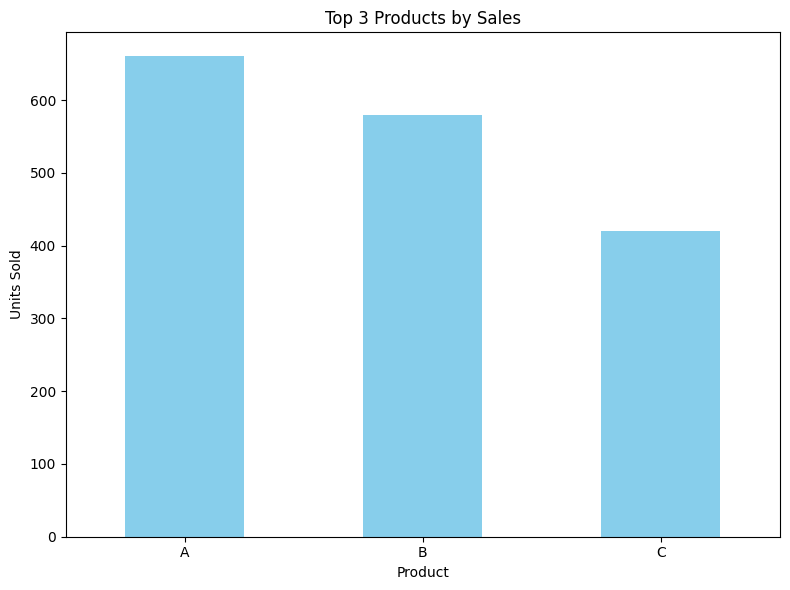

Result of execution: Product
A    660
B    580
C    420
Name: Units Sold, dtype: int64

{'messages': [HumanMessage(content='Supervisor Decision: Next Agent - code_executor, Reason - The query requires analyzing the sales data to identify the top 3 products by sales and then creating a bar plot based on their sales. This task involves data manipulation and visualization, which can be efficiently handled by writing and executing Python code on the provided Pandas DataFrames. Therefore, the Code Executor is the most suitable agent for this task.', additional_kwargs={}, response_metadata={}, name='Supervisor', id='5a2afc99-6550-4d9b-b6ec-2dbac3207213'), AIMessage(content='Product\nA    660\nB    580\nC    420\nName: Units Sold, dtype: int64\n', additional_kwargs={}, response_metadata={}, name='Python Code Extractor', id='2da2c11b-f452-413b-b0cf-02daef65175f')], 'query': 'what top 3 product by sales ? bar plot it based on its sales', 'uploaded_files_info': {'Embeddings': {'file_name': 'Embe

In [15]:

# Step 3: Use the graph with memory
thread_id = "thread_1"
config = {"configurable": {"thread_id": thread_id}}

# First input
input1 = {"query": "what top 3 product by sales ? bar plot it based on its sales"}
for event in app.stream(input1, config=config, stream_mode="values"):
    print(event)

In [16]:
# Second input (state will retain history)
# input2 = {"query": "What is the name of person i just asked?"}
# for event in app.stream(input2, config=config, stream_mode="values"):
#     print(event)

In [17]:
# from IPython.display import Image, display

# try:
#     display(Image(app.get_graph().draw_mermaid_png()))
# except Exception as e:
#     print("Rendering failed:", e)
#     # This requires graphviz and PIL installed

# from IPython.display import SVG, display
# from langgraph.graph.render import MermaidDrawMethod

# svg = app.get_graph().draw_mermaid_svg(draw_method=MermaidDrawMethod.API)  # or PYPPETEER for local
# display(SVG(svg))

In [18]:

# def make_serializable(obj):
#     if isinstance(obj, pd.DataFrame):
#         print(f"DataFrame found at: {id(obj)}")
#         return obj.to_dict(orient="records")
#     elif isinstance(obj, dict):
#         return {k: make_serializable(v) for k, v in obj.items()}
#     elif isinstance(obj, list):
#         return [make_serializable(v) for v in obj]
#     else:
#         return obj

# Your input with a DataFrame removed or converted
# raw_input = {
#     'query': 'when did spacex start?',
#     'context': ''
# }

# # serializable_input = make_serializable(raw_input)

# events = app.stream(raw_input, config, stream_mode='updates')

# for event in events:
#     print(event)

In [19]:
# response = app.invoke({
#     'query' : 'What is the top 3 category name and its total sales, based on sales?',
#     'context':''
# })

# response = app.invoke({
#     'query' : 'Merge the 2 provided csv file based on some key and give me final output?',
#     'context':''
# })

# response = app.invoke({
#     'query' : 'What is newyork weather?',
#     'context':''
# })

# response = app.invoke({
#     'query' : 'What is apple?',
#     'context':''
# })

In [20]:
import pprint
# pprint.pprint(response['output'])
pprint.pprint(event['output'])

'Product\nA    660\nB    580\nC    420\nName: Units Sold, dtype: int64\n'


In [21]:
# Retrieve state from memory checkpointer
# state = memory.get({"configurable": {"thread_id": "thread_1"}})

# # Add new question to the query list
# state["query"] = "Who is its CEO?"
# memory.put({"configurable": {"thread_id": "thread_1"}}, state)

In [22]:
# raw_input2 = {
#     'query': 'who is its ceo ?'
# }

# # serializable_input = make_serializable(raw_input)

# events1 = app.stream(raw_input2, config, stream_mode='values')

# for event1 in events1:
#     print(event1)

In [23]:
# import pprint
# pprint.pprint(event1['output'])

In [24]:
# response['output']

# from langchain_community.document_loaders import PyPDFLoader
# from langchain_openai import ChatOpenAI

# loader = PyPDFLoader("/Users/yogeshagrawal/Desktop/Gen AI/32.Agentic_AI/documents/Embeddings.pdf")

# docs = loader.load()

# print(docs[1])
# print(docs[0].page_content)
# print(docs[0].metadata)
